# Surface-volume layer viewer

Pass in a rendered surface-volume zarr id and a layer number to view that depth layer like a TIFF.

- `SCROLL_ID` = the rendered zarr under `ves_zarrs2/<id>.zarr` (shape `(D, H, W)`)
- `LAYER` = which depth slice to show (0 .. D-1). For a 96-layer render, layer 48 is the sheet surface (normal offset 0).

Also loads the prediction stack (`runs_infer/<id>/pred_stack.npy`) if present, so you can overlay the model's ink probability.

In [1]:
import os
import numpy as np
import zarr
import matplotlib.pyplot as plt
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

ZARR_ROOT = r"C:\Users\ChenJeff\Documents\ves_zarrs2"
SCROLL_ID = "20260715114436"   # PHerc0191 w044 small patch (96 layers)

vol = zarr.open(os.path.join(ZARR_ROOT, f"{SCROLL_ID}.zarr"), mode="r")
D, H, W = vol.shape
print(f"volume {SCROLL_ID}: shape (D={D}, H={H}, W={W}) dtype={vol.dtype}")
mask = None
mpath = f"./masks/{SCROLL_ID}.png"
if os.path.exists(mpath):
    mask = np.array(Image.open(mpath).convert("L")) > 0
    print(f"mask valid frac: {mask.mean():.3f}")

volume 20260715114436: shape (D=96, H=2181, W=2181) dtype=uint16
mask valid frac: 0.910


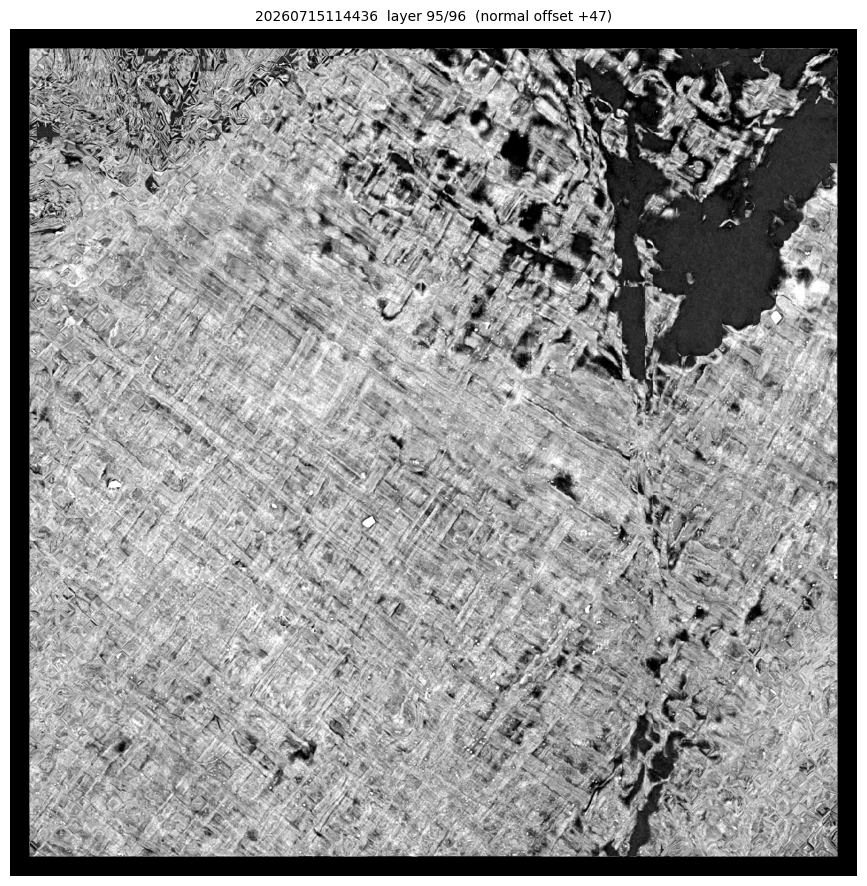

layer 95: min=0 max=255 mean(valid)=116.7


In [5]:
# ==== set the layer you want to view ====
LAYER = 95  # e.g. 48 for the 96-layer render (sheet surface). change freely: 0..D-1

layer = int(np.clip(LAYER, 0, D - 1))
img = np.asarray(vol[layer]).astype(np.float32)

# contrast stretch over valid (masked) pixels for visibility
sel = mask if mask is not None else (img > 0)
if sel.any():
    lo, hi = np.percentile(img[sel], [1, 99])
else:
    lo, hi = float(img.min()), float(img.max())
disp = np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

off = layer - D // 2  # normal offset relative to sheet surface
plt.figure(figsize=(11, 11 * H / max(W, 1)))
plt.imshow(disp, cmap="gray")
plt.title(f"{SCROLL_ID}  layer {layer}/{D}  (normal offset {off:+d})", fontsize=10)
plt.axis("off")
plt.show()
print(f"layer {layer}: min={img.min():.0f} max={img.max():.0f} mean(valid)={img[sel].mean():.1f}")

## Optional: scrub a range of layers as a contact sheet

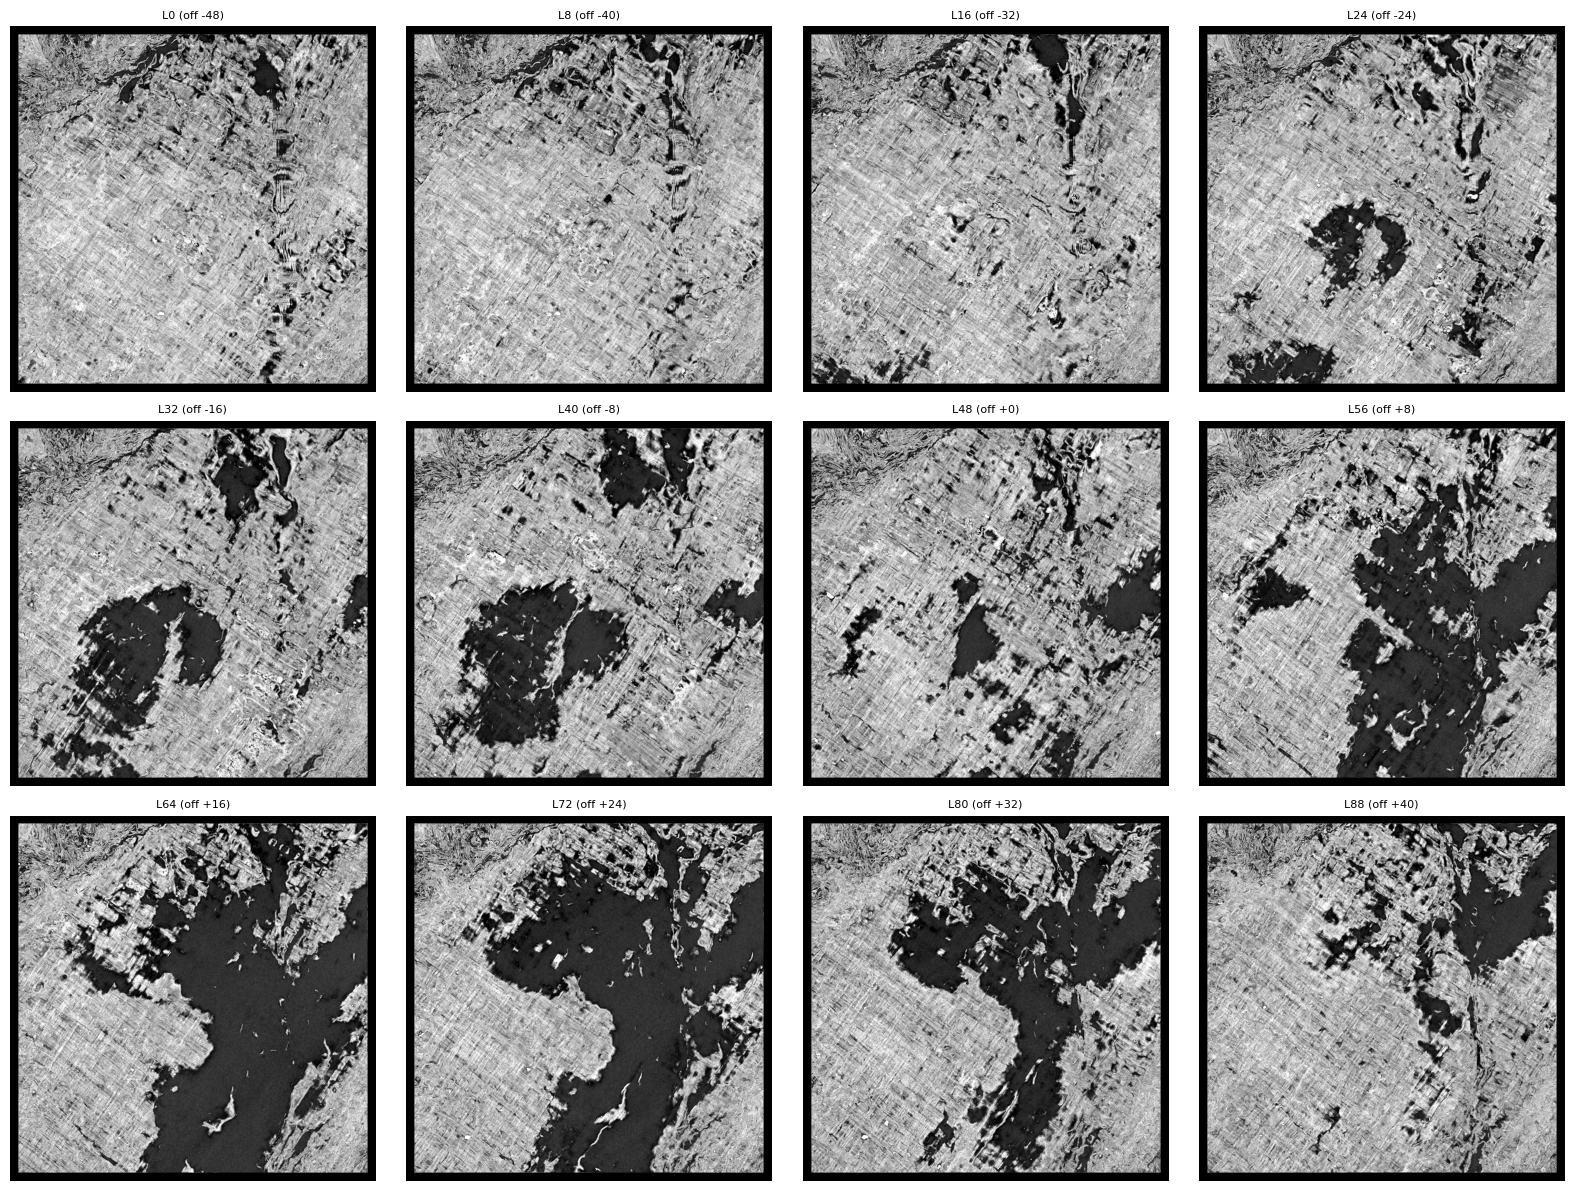

In [3]:
# show a grid of layers to find where the sheet / ink sits
START, STOP, STEP = 0, D, max(1, D // 12)
idxs = list(range(START, STOP, STEP))
cols = 4
rows = (len(idxs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
for ax, li in zip(np.array(axes).ravel(), idxs):
    im = np.asarray(vol[li]).astype(np.float32)
    s = mask if mask is not None else (im > 0)
    lo, hi = (np.percentile(im[s], [1, 99]) if s.any() else (im.min(), im.max()))
    ax.imshow(np.clip((im - lo) / (hi - lo + 1e-6), 0, 1), cmap="gray")
    ax.set_title(f"L{li} (off {li - D//2:+d})", fontsize=8)
    ax.axis("off")
for ax in np.array(axes).ravel()[len(idxs):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## Optional: overlay the model's ink prediction
Runs after `infer_scroll_sweep.py` has produced `runs_infer/<id>/pred_stack.npy` + `composite_max.png`.

In [4]:
stack_path = os.path.join("runs_infer", SCROLL_ID, "pred_stack.npy")
if os.path.exists(stack_path):
    stack = np.load(stack_path)   # (n_depths, h_small, w_small)
    comp = np.nanmax(stack, axis=0)
    print(f"pred stack {stack.shape}  global max ink-prob = {np.nanmax(comp):.3f}")
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    surf = np.asarray(vol[D // 2]).astype(np.float32)
    s = mask if mask is not None else (surf > 0)
    lo, hi = (np.percentile(surf[s], [1, 99]) if s.any() else (surf.min(), surf.max()))
    ax[0].imshow(np.clip((surf - lo) / (hi - lo + 1e-6), 0, 1), cmap="gray")
    ax[0].set_title("surface (layer D/2)"); ax[0].axis("off")
    im = ax[1].imshow(comp, cmap="inferno", vmin=0, vmax=1)
    ax[1].set_title("max ink-prob over all depths"); ax[1].axis("off")
    fig.colorbar(im, ax=ax[1], fraction=0.046)
    plt.tight_layout(); plt.show()
else:
    print(f"no prediction stack yet at {stack_path} — run infer_scroll_sweep.py first")

no prediction stack yet at runs_infer\20260715114436\pred_stack.npy — run infer_scroll_sweep.py first
